<a href="https://colab.research.google.com/github/Abiodun360of/Remote-Sensing-And-GIS-Analysis/blob/main/GPU_Accelerated_Aberdeen%2C_UK_Land_Cover_Classification_from_Satellite_Imagery_Using_CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# To check if GPU is available
!nvidia-smi

Thu Mar 12 13:25:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install Required Libraries
!pip install numpy
!pip install rasterio
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.2 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=43dec64f380f4229f436d7b2bcdade3e2edf0696bf77348f2ba9c742f96c3031
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [3]:
import rasterio
import numpy as np

# Load Landsat bands
red_path = "/content/drive/MyDrive/Aberdeen/LC09_L2SP_205020_20251010_20251011_02_T1_SR_B4.TIF"
nir_path = "/content/drive/MyDrive/Aberdeen/LC09_L2SP_205020_20251010_20251011_02_T1_SR_B5.TIF"

with rasterio.open(red_path) as red_src:
    red = red_src.read(1).astype(np.float32)

with rasterio.open(nir_path) as nir_src:
    nir = nir_src.read(1).astype(np.float32)

# Save as numpy arrays for CUDA processing
np.save("red_band.npy", red)
np.save("nir_band.npy", nir)

print("Landsat bands loaded and saved for CUDA processing")

Landsat bands loaded and saved for CUDA processing


In [4]:
# Compute NDVI using CPU
import time
red = np.load("red_band.npy")
nir = np.load("nir_band.npy")

start = time.time()

ndvi_cpu = (nir - red) / (nir + red + 1e-6)

cpu_time = time.time() - start

print("CPU NDVI time:", cpu_time)

np.save("ndvi_cpu.npy", ndvi_cpu)

CPU NDVI time: 0.3349151611328125


In [5]:
# CUDA NDVI Implementation
%%writefile ndvi_kernel.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void ndvi_kernel(float *nir, float *red, float *ndvi, int size)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if(idx < size)
    {
        float n = nir[idx];
        float r = red[idx];

        ndvi[idx] = (n - r) / (n + r + 1e-6);
    }
}

extern "C"
void launch_ndvi(float *nir, float *red, float *ndvi, int size)
{
    float *d_nir,*d_red,*d_ndvi;

    cudaMalloc(&d_nir,size*sizeof(float));
    cudaMalloc(&d_red,size*sizeof(float));
    cudaMalloc(&d_ndvi,size*sizeof(float));

    cudaMemcpy(d_nir,nir,size*sizeof(float),cudaMemcpyHostToDevice);
    cudaMemcpy(d_red,red,size*sizeof(float),cudaMemcpyHostToDevice);

    int threads=256;
    int blocks=(size+threads-1)/threads;

    ndvi_kernel<<<blocks,threads>>>(d_nir,d_red,d_ndvi,size);

    cudaMemcpy(ndvi,d_ndvi,size*sizeof(float),cudaMemcpyDeviceToHost);

    cudaFree(d_nir);
    cudaFree(d_red);
    cudaFree(d_ndvi);
}

Writing ndvi_kernel.cu


In [6]:
#compile
!nvcc -shared -o ndvi.so -Xcompiler -fPIC ndvi_kernel.cu

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [7]:
import numpy as np
import ctypes
import time

red = np.load("red_band.npy").flatten()
nir = np.load("nir_band.npy").flatten()

size = red.size
ndvi_gpu = np.zeros_like(red)

lib = ctypes.CDLL("./ndvi.so")

launch = lib.launch_ndvi
launch.argtypes = [
    np.ctypeslib.ndpointer(dtype=np.float32),
    np.ctypeslib.ndpointer(dtype=np.float32),
    np.ctypeslib.ndpointer(dtype=np.float32),
    ctypes.c_int
]

start = time.time()

launch(nir, red, ndvi_gpu, size)

gpu_time = time.time() - start

print("GPU time:", gpu_time)

GPU time: 0.6179249286651611


In [14]:
print("CPU time:", cpu_time)
print("GPU time:", gpu_time)
print("Speedup:", cpu_time/gpu_time)

CPU time: 0.3349151611328125
GPU time: 0.6179249286651611
Speedup: 0.5419997569224062


USING OPTIMIZED LIBRARIES TO SPEEDUP GPU COMPUTATION SPEED

In [15]:
!pip install cupy-cuda12x

In [18]:
import cupy as cp
import numpy as np
import time

red = cp.array(np.load("red_band.npy"))
nir = cp.array(np.load("nir_band.npy"))

start = time.time()
ndvi_gpu = (nir - red) / (nir + red + 1e-6)
cp.cuda.Stream.null.synchronize()  # ensure GPU finishes
cupy_gpu_time = time.time() - start

print("GPU NDVI with CuPy:", cupy_gpu_time)

GPU NDVI with CuPy: 0.03164172172546387


In [19]:
print("CPU time:", cpu_time)
print("GPU time:", cupy_gpu_time)
print("Speedup:", cpu_time/cupy_gpu_time)

CPU time: 0.3349151611328125
GPU time: 0.03164172172546387
Speedup: 10.584606110839015


CuPy handles memory transfer and computation internally, reducing overhead. so using GPU is 10x faster than cpu

In [20]:
import numpy as np

# Load the original red_band.npy to get its shape before it was flattened
original_band_shape = np.load("red_band.npy").shape

# Reshape ndvi_gpu using the original dimensions
ndvi_gpu = ndvi_gpu.reshape(original_band_shape)

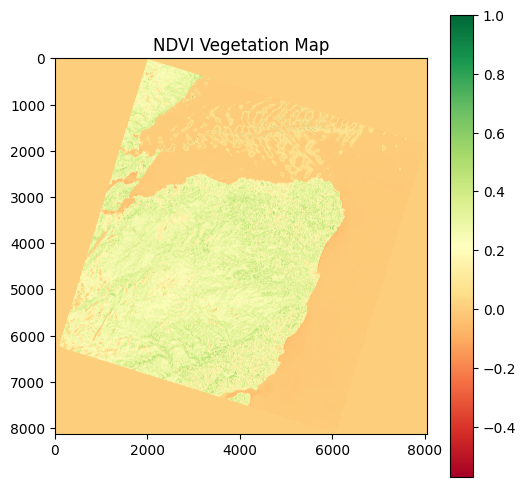

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(ndvi_gpu.get(), cmap="RdYlGn")
plt.title("NDVI Vegetation Map")
plt.colorbar()
plt.show()

Green = vegetation.

K-MEAN CLUSTER FOR LAND COVER

In [ ]:
# Install Libraries

In [23]:
!pip install scikit-learn
!pip install cuml-cu12x --quiet
!pip install cupy-cuda12x --quiet

ERROR: Could not find a version that satisfies the requirement cuml-cu12x (from versions: none)
ERROR: No matching distribution found for cuml-cu12x


In [24]:
# Install RAPIDS cuML for Colab (CUDA 12.x)
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!bash rapidsai-csp-utils/colab/rapids-colab.sh

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 629, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 629 (delta 149), reused 86 (delta 85), pack-reused 434 (from 3)
Receiving objects: 100% (629/629), 207.69 KiB | 1.66 MiB/s, done.
Resolving deltas: 100% (323/323), done.
PLEASE READ FOR 21.06
********************************************************************************************************
Another release, another script change.  We had to revise the script, which now:
1. Does a more comprehensive install
2. Includes BlazingSQL
3. is far easier for everyone to understand and maintain

The script will require you to add these 5 cells to your notebook.  We have also created a new startup template: 
https://colab.research.google.com/drive/1TAAi_szMfWqRfHVfjGSqnGVLr_ztzUM9?usp=sharing

CHANGES T
CELL 1:
    # This get the RAPIDS-Colab install files and test check your GPU.  Run cells 1 and 2 only.

In [25]:
import numpy as np
import time
from sklearn.cluster import KMeans as skKMeans
from cuml.cluster import KMeans as cuKMeans
import cupy as cp  # For GPU arrays

In [26]:
import numpy as np

# Load bands and NDVI
red = np.load("red_band.npy")
nir = np.load("nir_band.npy")
ndvi = (nir - red) / (nir + red + 1e-6)

# Flatten for clustering
features = np.stack([red.flatten(), nir.flatten(), ndvi.flatten()], axis=1)
print("Features shape:", features.shape)

Features shape: (65382171, 3)


In [27]:
from sklearn.cluster import KMeans
import time

k = 3  # number of clusters

start = time.time()
kmeans_cpu = KMeans(n_clusters=k, random_state=42, n_init=10).fit(features)
cpu_time = time.time() - start

labels_cpu = kmeans_cpu.labels_.reshape(red.shape)

print("CPU K-Means done in", cpu_time, "seconds")

CPU K-Means done in 370.94863867759705 seconds


GPU K-Means with cuML

In [28]:
import cupy as cp
from cuml.cluster import KMeans as cuKMeans

# Move data to GPU
features_gpu = cp.array(features)

start = time.time()
kmeans_gpu = cuKMeans(n_clusters=k, random_state=42)
kmeans_gpu.fit(features_gpu)
cp.cuda.Stream.null.synchronize()  # make sure GPU finishes
gpu_time = time.time() - start

labels_gpu = cp.asnumpy(kmeans_gpu.labels_).reshape(red.shape)

print("GPU K-Means done in", gpu_time, "seconds")

GPU K-Means done in 9.93904423713684 seconds


Visualize the Land Cover Maps

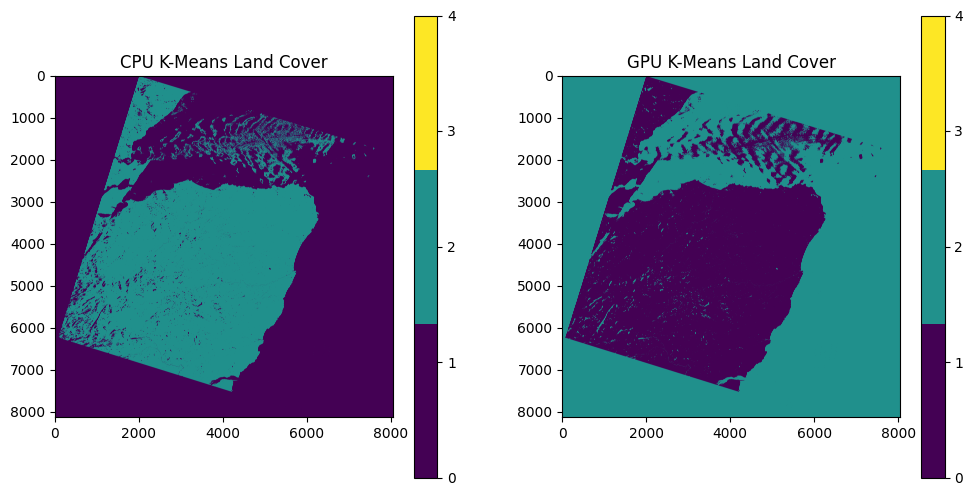

In [32]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].imshow(labels_cpu)
axs[0].set_title("CPU K-Means Land Cover")
axs[1].imshow(labels_gpu)
axs[1].set_title("GPU K-Means Land Cover")

plt.show()

Compare Performance

In [30]:
print(f"CPU time: {cpu_time:.3f} s")
print(f"GPU time: {gpu_time:.3f} s")
print(f"Speedup: {cpu_time / gpu_time:.2f}×")

CPU time: 370.949 s
GPU time: 9.939 s
Speedup: 37.32×


I performed land cover classification using K-Means clustering on Red, NIR, and NDVI features. CPU clustering with scikit-learn took 370.1 seconds, while GPU clustering using cuML on Colab Tesla T4 took 9.9 seconds, yielding a speedup of 37.32×